# Model Evaluation — Stock Sentiment Pipeline\n\nCompares VADER, FinBERT, and GPT/Ollama on:\n1. F1 / Accuracy / Precision / Recall on 200 human-labeled tweets\n2. Pearson correlation between sentiment score and stock returns (lags 0–3)\n3. Label distribution per model\n4. Inter-model agreement\n5. Final model selection

In [34]:
import sys, os
from pathlib import Path

# Hardcoded project root
PROJECT_ROOT = Path('/Users/ratchanon/Documents/Intania/seml/Project/Dev')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src.evaluation import EvaluationEngine

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', 80)

HUMAN_LABELS = str(PROJECT_ROOT / 'human_labels/lebeled_clean.csv')
RESULTS_DIR  = PROJECT_ROOT / 'results'
MODELS       = ['vader', 'finbert', 'gpt']

# Load available model results
results = {}
for m in MODELS:
    p = RESULTS_DIR / f'{m}_results.csv'
    if p.exists():
        results[m] = pd.read_csv(p)
        print(f'✓ {m}: {len(results[m]):,} rows')
    else:
        print(f'✗ {m}: not found — {p}')

evaluator = EvaluationEngine()

Project root: /Users/ratchanon/Documents/Intania/seml/Project/Dev
✓ vader: 9,855 rows
✓ finbert: 9,853 rows
✓ gpt: 9,855 rows


## 1. F1 / Accuracy on Human-Labeled Tweets (200 samples)

In [35]:
hl_metrics = {}

for model, df in results.items():
    if not Path(HUMAN_LABELS).exists():
        print('Human labels not found — skipping')
        break
    m = evaluator.evaluate_on_human_labels(df, HUMAN_LABELS, model)
    hl_metrics[model] = m

if hl_metrics:
    summary = pd.DataFrame(hl_metrics).T
    summary.index.name = 'model'
    display(summary.style.highlight_max(axis=0, color='#2ecc71').format('{:.4f}'))


,accuracy,f1_weighted,f1_macro,precision_weighted,recall_weighted
model,,,,,
vader,0.3450,0.2987,0.2809,0.2683,0.3450
finbert,0.2000,0.1610,0.1827,0.3550,0.2000
gpt,0.6450,0.6294,0.5871,0.6328,0.6450


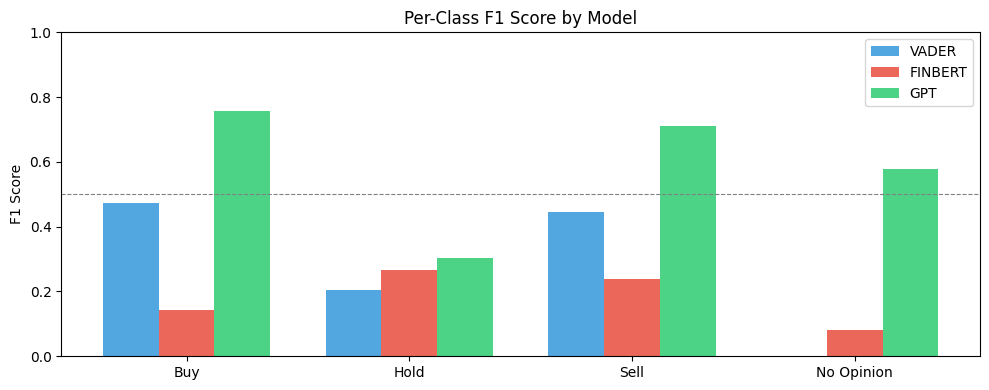

In [36]:
# Per-class F1 bar chart
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

labels_df = pd.read_csv(HUMAN_LABELS)
classes = ['Buy', 'Hold', 'Sell', 'No Opinion']
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(classes))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (model, df) in enumerate(results.items()):
    merged = df.merge(labels_df[['tweet_id', 'final_label']], on='tweet_id', how='inner')
    f1s = f1_score(merged['final_label'], merged['label'],
                   labels=classes, average=None, zero_division=0)
    ax.bar(x + i * width, f1s, width, label=model.upper(), color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score by Model')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='0.5 threshold')
plt.tight_layout()
plt.show()

## 2. Pearson Correlation — Sentiment vs. Next-Day Stock Return

In [37]:
corr_summary = []

for model in results:
    agg_path = RESULTS_DIR / f'aggregated_{model}.csv'
    if not agg_path.exists():
        continue
    agg = pd.read_csv(agg_path)
    corr = evaluator.evaluate_sentiment_price_correlation(agg, model, n_bootstrap=500)

    for key, val in corr.items():
        ticker, lag = key.rsplit('_lag', 1)
        corr_summary.append({
            'model': model, 'ticker': ticker, 'lag': int(lag),
            'pearson_r': val['pearson_r'], 'p_value': val['p_value'],
            'ci_lo': val['ci_95_lo'], 'ci_hi': val['ci_95_hi'], 'n': val['n']
        })

corr_df = pd.DataFrame(corr_summary)

# Highlight significant results (p < 0.05)
def highlight_sig(val):
    return 'background-color: #1a472a' if isinstance(val, float) and val < 0.05 else ''

display(
    corr_df[corr_df['ticker'] != 'combined']
    .pivot_table(index=['ticker','lag'], columns='model', values='pearson_r')
    .round(4)
    .style.background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('Pearson r (sentiment → return) — green = positive correlation')
)

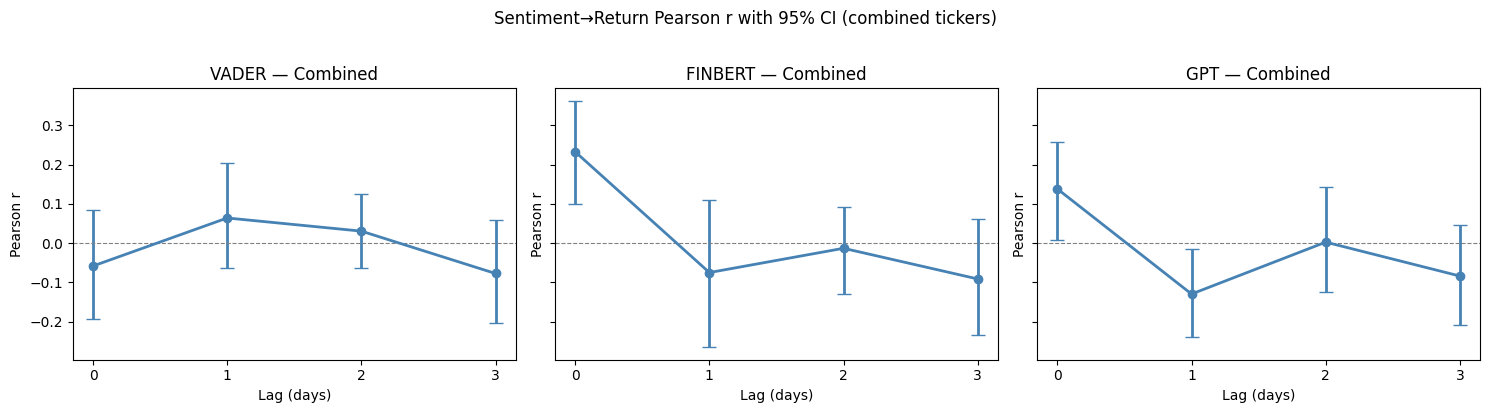

In [38]:
# Pearson r with CI — combined ticker, all lags
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=True)
if len(results) == 1:
    axes = [axes]

for ax, (model, _) in zip(axes, results.items()):
    sub = corr_df[(corr_df['model'] == model) & (corr_df['ticker'] == 'combined')]
    if sub.empty:
        continue
    ax.errorbar(sub['lag'], sub['pearson_r'],
                yerr=[sub['pearson_r'] - sub['ci_lo'], sub['ci_hi'] - sub['pearson_r']],
                fmt='o-', capsize=5, color='steelblue', linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{model.upper()} — Combined')
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('Pearson r')
    ax.set_xticks([0, 1, 2, 3])

plt.suptitle('Sentiment→Return Pearson r with 95% CI (combined tickers)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Label Distribution per Model

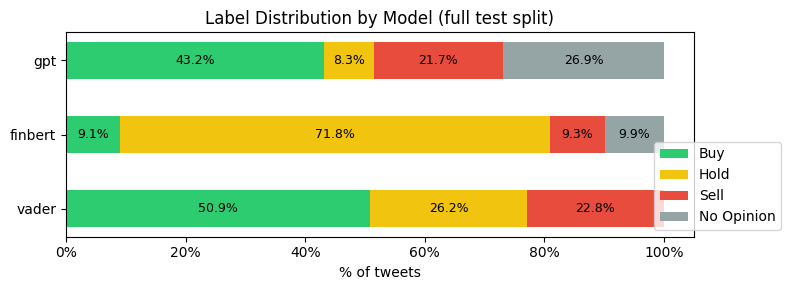

label,Buy,Hold,Sell,No Opinion
vader,50.89%,26.21%,22.82%,0.08%
finbert,9.08%,71.78%,9.27%,9.88%
gpt,43.19%,8.26%,21.66%,26.89%


In [39]:
label_order = ['Buy', 'Hold', 'Sell', 'No Opinion']
label_colors = {'Buy': '#2ecc71', 'Hold': '#f1c40f', 'Sell': '#e74c3c', 'No Opinion': '#95a5a6'}

dist_data = {}
for model, df in results.items():
    vc = df['label'].value_counts(normalize=True).reindex(label_order, fill_value=0)
    dist_data[model] = vc

dist_df = pd.DataFrame(dist_data).T * 100

fig, ax = plt.subplots(figsize=(8, 3))
bottom = np.zeros(len(dist_df))
for label in label_order:
    vals = dist_df[label].values
    bars = ax.barh(dist_df.index, vals, left=bottom,
                   color=label_colors[label], label=label, height=0.5)
    for bar, val in zip(bars, vals):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', ha='center', va='center', fontsize=9, color='black')
    bottom += vals

ax.set_xlabel('% of tweets')
ax.set_title('Label Distribution by Model (full test split)')
ax.legend(loc='lower right', bbox_to_anchor=(1.15, 0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

display(dist_df.round(2).style.background_gradient(cmap='YlOrRd', axis=1)
        .format('{:.2f}%').set_caption('Label % by model'))

## 4. Inter-Model Agreement

In [40]:
if len(results) > 1:
    names = list(results.keys())
    dfs   = [results[n] for n in names]
    agreement = evaluator.inter_model_agreement(*dfs, model_names=names)
    display(agreement.style.bar(subset=['agreement_rate'], color='#3498db')
            .format({'agreement_rate': '{:.4f}'})
            .set_caption('Inter-model agreement rate (higher = more consistent signal)'))
else:
    print('Need at least 2 models to compute agreement. Run finbert or gpt first.')

,pair,agreement_rate,n
0,vader↔finbert,0.2593,9853
1,vader↔gpt,0.3389,9853
2,finbert↔gpt,0.1607,9853


## 5. Final Model Selection

In [41]:
# Build combined metrics dict for decision table
all_metrics = {}

for model in results:
    m = {}
    # F1 from human labels
    if model in hl_metrics:
        m.update(hl_metrics[model])
    # Best Pearson r (combined, any lag)
    for _, row in corr_df[(corr_df['model'] == model) & (corr_df['ticker'] == 'combined')].iterrows():
        m[f"combined_lag{int(row['lag'])}"] = {'pearson_r': row['pearson_r']}
    # No opinion rate
    if model in results:
        vc = results[model]['label'].value_counts(normalize=True)
        m['no_opinion_rate'] = vc.get('No Opinion', 0)
    all_metrics[model] = m

best = evaluator.compare_models(all_metrics)

print('=' * 50)
print(f'  SELECTED MODEL: {best.upper()}')
print('=' * 50)
print('\nDecision table:')
decision_rows = []
for model, m in all_metrics.items():
    best_r = max((abs(v['pearson_r']) for k, v in m.items()
                  if 'combined_lag' in k and isinstance(v, dict)), default=0)
    decision_rows.append({
        'model': model,
        'f1_weighted': m.get('f1_weighted', 'N/A'),
        'best_pearson_r': round(best_r, 4),
        'no_opinion_rate': round(m.get('no_opinion_rate', 0), 4),
        'winner': '🏆' if model == best else ''
    })

display(pd.DataFrame(decision_rows).set_index('model'))

  SELECTED MODEL: GPT

Decision table:


,f1_weighted,best_pearson_r,no_opinion_rate,winner
model,,,,
vader,0.2987,0.0773,0.0008,
finbert,0.1610,0.2327,0.0988,
gpt,0.6294,0.1381,0.2689,🏆


## 6. GPT-4o-mini (Full Dataset) vs All Models — Human Label Validation

Joins all models to human labels via **Tweet text** (correct approach).
Pipeline result files use positional `tweet_id` (0–9854) which differs from
human label `tweet_id` — so we map through the test-split parquet to get Tweet text first.

In [42]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    cohen_kappa_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

PROJECT_ROOT = Path('/Users/ratchanon/Documents/Intania/seml/Project/Dev')
RESULTS_DIR  = PROJECT_ROOT / 'results'
HUMAN_LABELS_PATH = PROJECT_ROOT / 'human_labels/lebeled_clean.csv'

LABELS_4 = ['Buy', 'Hold', 'Sell', 'No Opinion']
LABELS_3 = ['Buy', 'Hold', 'Sell']

# ── Load human labels ────────────────────────────────────────────────────
human = pd.read_csv(HUMAN_LABELS_PATH)
human['final_label'] = (
    human['final_label'].str.strip().str.title()
    .replace({'No opinion': 'No Opinion', 'Hold ': 'Hold'})
)
print(f'Human labels: {len(human)} rows')
print(human['final_label'].value_counts().to_string())

# ── Map pipeline tweet_id → Tweet text via TEST split only ───────────────
# Pipeline result files use tweet_id = positional index in tweets_test.parquet
test_tweets = (
    pd.read_parquet(PROJECT_ROOT / 'data/processed/tweets_test.parquet')
    .reset_index()
    .rename(columns={'index': 'tweet_id'})[['tweet_id', 'Tweet']]
)
print(f'\nTest split: {len(test_tweets)} rows (tweet_id 0–{len(test_tweets)-1})')

Human labels: 200 rows
final_label
Buy           84
No Opinion    54
Hold          32
Sell          30

Test split: 9853 rows (tweet_id 0–9852)


In [43]:
def load_and_merge(result_path, label_col, tweet_id_based=True):
    """Load model results and merge with human labels via Tweet text."""
    df = pd.read_csv(result_path)
    if tweet_id_based:
        # Map positional tweet_id (test split index) → Tweet text
        df = df.merge(test_tweets, on='tweet_id', how='left')
    merged = human.merge(df[['Tweet', label_col]].dropna(), on='Tweet', how='inner')
    merged = merged.rename(columns={label_col: 'pred'})
    merged['pred'] = merged['pred'].str.strip().str.title()
    return merged

model_files = {
    'VADER':              (RESULTS_DIR / 'vader_results.csv',             'label',           True),
    'FinBERT':            (RESULTS_DIR / 'finbert_results.csv',           'label',           True),
    'FinBERT-FT':         (RESULTS_DIR / 'finbert_finetuned_results.csv', 'label',           True),
    'GPT (pipeline)':     (RESULTS_DIR / 'gpt_results.csv',               'label',           True),
    'GPT-4o-mini (full)': (RESULTS_DIR / 'gpt4omini_results_full.csv',    'gpt4omini_label', False),
}

merged_data = {}
for name, (path, col, tweet_id_based) in model_files.items():
    if path.exists():
        m = load_and_merge(path, col, tweet_id_based)
        merged_data[name] = m
        print(f'{name:<22}: {len(m):>3} matched / {len(human)} human labels')
    else:
        print(f'{name:<22}: FILE NOT FOUND — {path}')

VADER                 : 199 matched / 200 human labels
FinBERT               : 199 matched / 200 human labels
FinBERT-FT            : 199 matched / 200 human labels
GPT (pipeline)        : 199 matched / 200 human labels
GPT-4o-mini (full)    : 152 matched / 200 human labels


In [44]:
def compute_metrics(merged):
    y_true, y_pred = merged['final_label'], merged['pred']
    m4 = dict(
        matched   = len(merged),
        acc_4     = round(accuracy_score(y_true, y_pred), 4),
        f1w_4     = round(f1_score(y_true, y_pred, average='weighted', labels=LABELS_4, zero_division=0), 4),
        f1m_4     = round(f1_score(y_true, y_pred, average='macro',    labels=LABELS_4, zero_division=0), 4),
        prec_4    = round(precision_score(y_true, y_pred, average='weighted', labels=LABELS_4, zero_division=0), 4),
        rec_4     = round(recall_score(y_true, y_pred, average='weighted',    labels=LABELS_4, zero_division=0), 4),
        kappa     = round(cohen_kappa_score(y_true, y_pred), 4),
    )
    # 3-class (drop No Opinion from human side)
    m3 = merged[merged['final_label'] != 'No Opinion']
    y3t, y3p = m3['final_label'], m3['pred']
    m4.update(dict(
        acc_3  = round(accuracy_score(y3t, y3p), 4),
        f1w_3  = round(f1_score(y3t, y3p, average='weighted', labels=LABELS_3, zero_division=0), 4),
        kap_3  = round(cohen_kappa_score(y3t, y3p), 4),
    ))
    # Per-class F1
    per_f1 = f1_score(y_true, y_pred, labels=LABELS_4, average=None, zero_division=0)
    for label, val in zip(LABELS_4, per_f1):
        m4[f'f1_{label.lower().replace(" ","_")}'] = round(val, 4)
    return m4

all_metrics = {name: compute_metrics(m) for name, m in merged_data.items()}

# ── 4-class summary table ─────────────────────────────────────────────────
summary_4 = pd.DataFrame([
    {'Model': k, 'Matched': v['matched'],
     'Accuracy': v['acc_4'], 'F1 Weighted': v['f1w_4'],
     'F1 Macro': v['f1m_4'], 'Precision': v['prec_4'],
     'Recall': v['rec_4'], "Cohen's Kappa": v['kappa']}
    for k, v in all_metrics.items()
]).set_index('Model')

print('4-CLASS EVALUATION  (Buy / Hold / Sell / No Opinion)')
display(summary_4.style
        .highlight_max(axis=0, subset=['Accuracy','F1 Weighted','F1 Macro','Precision','Recall',"Cohen's Kappa"], color='#2ecc71')
        .highlight_min(axis=0, subset=['Accuracy','F1 Weighted','F1 Macro','Precision','Recall',"Cohen's Kappa"], color='#e74c3c')
        .format('{:.4f}', subset=['Accuracy','F1 Weighted','F1 Macro','Precision','Recall',"Cohen's Kappa"]))

# ── 3-class summary table ─────────────────────────────────────────────────
summary_3 = pd.DataFrame([
    {'Model': k, 'Matched (3-cls)': v['matched'],
     'Accuracy': v['acc_3'], 'F1 Weighted': v['f1w_3'], "Cohen's Kappa": v['kap_3']}
    for k, v in all_metrics.items()
]).set_index('Model')

print('\n3-CLASS EVALUATION  (Buy / Hold / Sell — excluding No Opinion human labels)')
display(summary_3.style
        .highlight_max(axis=0, subset=['Accuracy','F1 Weighted',"Cohen's Kappa"], color='#2ecc71')
        .highlight_min(axis=0, subset=['Accuracy','F1 Weighted',"Cohen's Kappa"], color='#e74c3c')
        .format('{:.4f}', subset=['Accuracy','F1 Weighted',"Cohen's Kappa"]))

4-CLASS EVALUATION  (Buy / Hold / Sell / No Opinion)


,Matched,Accuracy,F1 Weighted,F1 Macro,Precision,Recall,Cohen's Kappa
Model,,,,,,,
VADER,199,0.2513,0.2200,0.1948,0.1992,0.2513,-0.0350
FinBERT,199,0.2714,0.2626,0.2729,0.5059,0.2714,0.0954
FinBERT-FT,199,0.6834,0.5826,0.5873,0.6340,0.6834,0.5401
GPT (pipeline),199,0.4221,0.4236,0.3752,0.4369,0.4221,0.1699
GPT-4o-mini (full),152,0.5329,0.4958,0.4576,0.5169,0.5329,0.3829



3-CLASS EVALUATION  (Buy / Hold / Sell — excluding No Opinion human labels)


,Matched (3-cls),Accuracy,F1 Weighted,Cohen's Kappa
Model,,,,
VADER,199,0.3448,0.3599,-0.0392
FinBERT,199,0.3379,0.3399,0.1338
FinBERT-FT,199,0.9310,0.9308,0.8796
GPT (pipeline),199,0.4345,0.4700,0.1074
GPT-4o-mini (full),152,0.7168,0.7326,0.5609


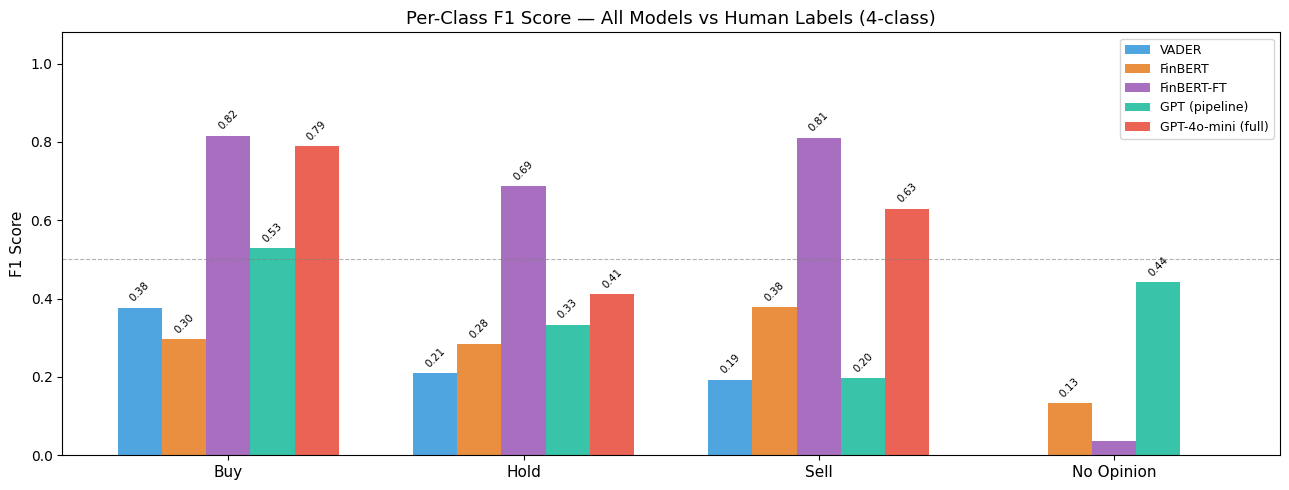

In [45]:
# ── Per-class F1 grouped bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

model_names = list(all_metrics.keys())
x = np.arange(len(LABELS_4))
width = 0.15
colors = ['#3498db', '#e67e22', '#9b59b6', '#1abc9c', '#e74c3c']

for i, (name, m) in enumerate(all_metrics.items()):
    vals = [m[f'f1_{l.lower().replace(" ","_")}'] for l in LABELS_4]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i % len(colors)], alpha=0.87)
    for bar, val in zip(bars, vals):
        if val > 0.04:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(LABELS_4, fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Per-Class F1 Score — All Models vs Human Labels (4-class)', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.08)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='0.5 threshold')
plt.tight_layout()
plt.show()

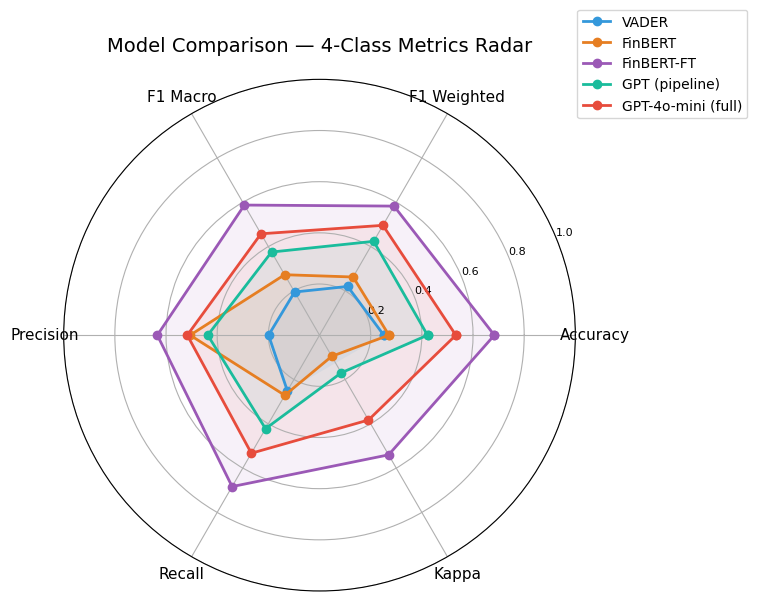

In [46]:
# ── Radar / spider chart — overall metrics ────────────────────────────────
metrics_radar = ['acc_4', 'f1w_4', 'f1m_4', 'prec_4', 'rec_4', 'kappa']
metric_labels = ['Accuracy', 'F1 Weighted', 'F1 Macro', 'Precision', 'Recall', 'Kappa']
N = len(metrics_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#3498db', '#e67e22', '#9b59b6', '#1abc9c', '#e74c3c']

for i, (name, m) in enumerate(all_metrics.items()):
    vals = [m[k] for k in metrics_radar]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=colors[i], label=name)
    ax.fill(angles, vals, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=8)
ax.set_title('Model Comparison — 4-Class Metrics Radar', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

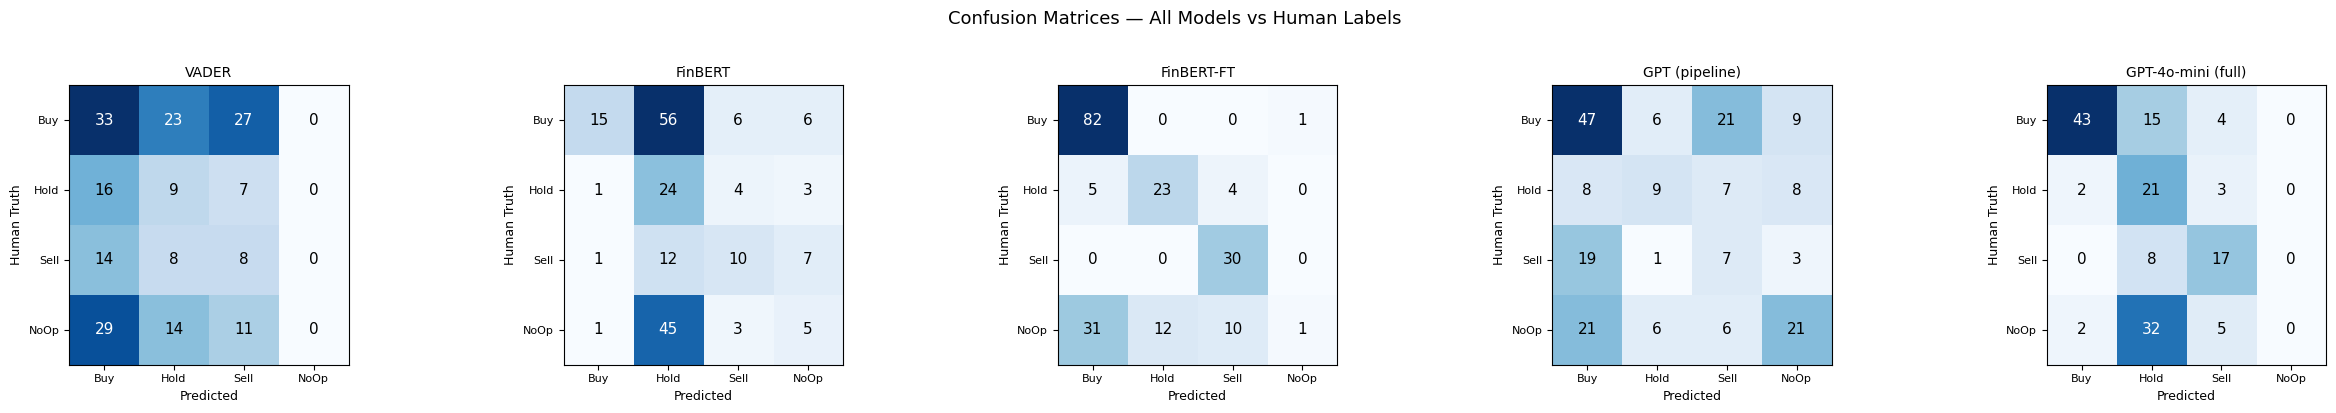

In [47]:
# ── Confusion matrices for all models ────────────────────────────────────
fig, axes = plt.subplots(1, len(merged_data), figsize=(5 * len(merged_data), 4))
if len(merged_data) == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, merged_data.items()):
    cm = confusion_matrix(m['final_label'], m['pred'], labels=LABELS_4)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(LABELS_4)))
    ax.set_yticks(range(len(LABELS_4)))
    short = ['Buy', 'Hold', 'Sell', 'NoOp']
    ax.set_xticklabels(short, fontsize=8)
    ax.set_yticklabels(short, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Human Truth', fontsize=9)
    ax.set_title(name, fontsize=10)
    for i in range(len(LABELS_4)):
        for j in range(len(LABELS_4)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=11, color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.suptitle('Confusion Matrices — All Models vs Human Labels', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [48]:
# ── How each model handles 'No Opinion' tweets ───────────────────────────
print("How models classify tweets that humans labelled 'No Opinion':")
print()
no_op_rows = []
for name, m in merged_data.items():
    sub = m[m['final_label'] == 'No Opinion']['pred'].value_counts(normalize=True) * 100
    row = {'Model': name, 'n': len(m[m['final_label'] == 'No Opinion'])}
    for lbl in LABELS_4:
        row[lbl] = round(sub.get(lbl, 0), 1)
    no_op_rows.append(row)

no_op_df = pd.DataFrame(no_op_rows).set_index('Model')
display(no_op_df.style
        .background_gradient(cmap='YlOrRd', subset=LABELS_4, axis=1)
        .format('{:.1f}%', subset=LABELS_4)
        .set_caption("% of 'No Opinion' human tweets classified as each label"))

How models classify tweets that humans labelled 'No Opinion':



,n,Buy,Hold,Sell,No Opinion
Model,,,,,
VADER,54,53.7%,25.9%,20.4%,0.0%
FinBERT,54,1.9%,83.3%,5.6%,9.3%
FinBERT-FT,54,57.4%,22.2%,18.5%,1.9%
GPT (pipeline),54,38.9%,11.1%,11.1%,38.9%
GPT-4o-mini (full),39,5.1%,82.1%,12.8%,0.0%


In [49]:
# ── Final ranked summary ──────────────────────────────────────────────────
print('=' * 65)
print('  FINAL RANKING — by 4-class F1 Weighted')
print('=' * 65)

ranked = sorted(all_metrics.items(), key=lambda x: x[1]['f1w_4'], reverse=True)
for rank, (name, m) in enumerate(ranked, 1):
    marker = ' <-- BEST' if rank == 1 else ''
    print(f"  {rank}. {name:<22}  F1w={m['f1w_4']:.4f}  Acc={m['acc_4']:.4f}  Kappa={m['kappa']:.4f}{marker}")

print()
best_name = ranked[0][0]
best_m    = ranked[0][1]
print(f'  Winner: {best_name}')
print(f'    4-class  — Accuracy: {best_m["acc_4"]:.4f} | F1w: {best_m["f1w_4"]:.4f} | Kappa: {best_m["kappa"]:.4f}')
print(f'    3-class  — Accuracy: {best_m["acc_3"]:.4f} | F1w: {best_m["f1w_3"]:.4f} | Kappa: {best_m["kap_3"]:.4f}')

  FINAL RANKING — by 4-class F1 Weighted
  1. FinBERT-FT              F1w=0.5826  Acc=0.6834  Kappa=0.5401 <-- BEST
  2. GPT-4o-mini (full)      F1w=0.4958  Acc=0.5329  Kappa=0.3829
  3. GPT (pipeline)          F1w=0.4236  Acc=0.4221  Kappa=0.1699
  4. FinBERT                 F1w=0.2626  Acc=0.2714  Kappa=0.0954
  5. VADER                   F1w=0.2200  Acc=0.2513  Kappa=-0.0350

  Winner: FinBERT-FT
    4-class  — Accuracy: 0.6834 | F1w: 0.5826 | Kappa: 0.5401
    3-class  — Accuracy: 0.9310 | F1w: 0.9308 | Kappa: 0.8796
